In [1]:
import math
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linprog, minimize

## Data basis for this assignment

This assignment uses public freight and logistics data sources from:

- United States Census Bureau: https://data.census.gov/table
- Bureau of Transportation Statistics: https://www.bts.gov/topics/freight-transportation

The public datasets are used as the empirical basis for the supply chain optimization problem.  
A simplified regional logistics dataset is then constructed in Python for optimization modeling, including warehouse locations, customer demand, transportation cost estimates, capacity limits, and delivery constraints.

In [2]:
warehouses = pd.DataFrame({
    "warehouse": ["Atlanta", "Chicago", "Dallas", "Harrisburg", "Kansas City"],
    "lat": [33.7490, 41.8781, 32.7767, 40.2732, 39.0997],
    "lon": [-84.3880, -87.6298, -96.7970, -76.8867, -94.5786],
    "capacity": [260, 220, 240, 200, 200],
    "fixed_cost": [5000, 5200, 5100, 4700, 4600],
})

customers = pd.DataFrame({
    "customer": ["Charlotte", "Miami", "Nashville", "New Orleans", "St. Louis"],
    "lat": [35.2271, 25.7617, 36.1627, 29.9511, 38.6270],
    "lon": [-80.8431, -80.1918, -86.7816, -90.0715, -90.1994],
    "demand": [160, 140, 130, 110, 150],
})

COST_PER_MILE_PER_UNIT = 2.20
MAX_ROUTE_MILES = 900

print("Warehouses")
display(warehouses)

print("Customers")
display(customers)

Warehouses


,warehouse,lat,lon,capacity,fixed_cost
0,Atlanta,33.7490,-84.3880,260,5000
1,Chicago,41.8781,-87.6298,220,5200
2,Dallas,32.7767,-96.7970,240,5100
3,Harrisburg,40.2732,-76.8867,200,4700
4,Kansas City,39.0997,-94.5786,200,4600


Customers


,customer,lat,lon,demand
0,Charlotte,35.2271,-80.8431,160
1,Miami,25.7617,-80.1918,140
2,Nashville,36.1627,-86.7816,130
3,New Orleans,29.9511,-90.0715,110
4,St. Louis,38.6270,-90.1994,150


### Step 3: Define a distance calculation function

In this step, a Haversine distance function is created to calculate the approximate distance in miles between each warehouse and customer location based on latitude and longitude.

This is necessary because transportation cost in the optimization model will be based on route distance.  
The distance values will also be used to determine whether a route satisfies the delivery constraint.

In [3]:
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles

    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.asin(math.sqrt(a))

    return R * c

### Step 4: Build route distances, transportation costs, and feasibility

In this step, all possible warehouse-to-customer routes are created.

For each route, the notebook calculates:
- distance in miles,
- transportation cost per unit,
- and whether the route is feasible under the delivery constraint.

This step transforms the raw warehouse and customer tables into a route-level dataset that can be used in the optimization models.

In [4]:
dist_rows = []

for _, w in warehouses.iterrows():
    for _, c in customers.iterrows():
        miles = haversine_miles(w["lat"], w["lon"], c["lat"], c["lon"])
        feasible = miles <= MAX_ROUTE_MILES

        dist_rows.append({
            "warehouse": w["warehouse"],
            "customer": c["customer"],
            "miles": miles,
            "cost_per_unit": miles * COST_PER_MILE_PER_UNIT,
            "feasible": feasible
        })

routes = pd.DataFrame(dist_rows)

print("Route-level dataset")
display(routes.round(2))

Route-level dataset


,warehouse,customer,miles,cost_per_unit,feasible
0,Atlanta,Charlotte,226.22,497.69,True
1,Atlanta,Miami,606.39,1334.06,True
2,Atlanta,Nashville,214.89,472.76,True
3,Atlanta,New Orleans,424.28,933.42,True
4,Atlanta,St. Louis,467.36,1028.18,True
5,Chicago,Charlotte,587.50,1292.51,True
6,Chicago,Miami,1191.37,2621.02,False
7,Chicago,Nashville,397.51,874.52,True
8,Chicago,New Orleans,835.23,1837.51,True
9,Chicago,St. Louis,262.30,577.07,True


### Step 5: Create distance, cost, and feasibility matrices

In this step, the route-level dataset is reshaped into matrix form.

These matrices make the optimization model easier to build because they let us quickly look up:
- distance from each warehouse to each customer,
- cost per unit for each route,
- and whether a route is allowed.

This step prepares the data for the linear programming model.

In [5]:
distance_matrix = routes.pivot(index="warehouse", columns="customer", values="miles").round(2)
cost_matrix = routes.pivot(index="warehouse", columns="customer", values="cost_per_unit").round(2)
feasibility_matrix = routes.pivot(index="warehouse", columns="customer", values="feasible")

print("Distance Matrix")
display(distance_matrix)

print("Cost Matrix")
display(cost_matrix)

print("Feasibility Matrix")
display(feasibility_matrix)

Distance Matrix


customer,Charlotte,Miami,Nashville,New Orleans,St. Louis
warehouse,,,,,
Atlanta,226.22,606.39,214.89,424.28,467.36
Chicago,587.50,1191.37,397.51,835.23,262.30
Dallas,928.32,1110.18,616.21,442.09,547.79
Harrisburg,410.11,1020.56,607.09,1029.29,718.61
Kansas City,801.25,1243.03,472.22,681.94,237.83


Cost Matrix


customer,Charlotte,Miami,Nashville,New Orleans,St. Louis
warehouse,,,,,
Atlanta,497.69,1334.06,472.76,933.42,1028.18
Chicago,1292.51,2621.02,874.52,1837.51,577.07
Dallas,2042.31,2442.40,1355.67,972.59,1205.14
Harrisburg,902.24,2245.23,1335.59,2264.45,1580.94
Kansas City,1762.75,2734.67,1038.89,1500.27,523.22


Feasibility Matrix


customer,Charlotte,Miami,Nashville,New Orleans,St. Louis
warehouse,,,,,
Atlanta,True,True,True,True,True
Chicago,True,False,True,True,True
Dallas,False,False,True,True,True
Harrisburg,True,False,True,False,True
Kansas City,True,False,True,True,True


### Step 6: Prepare optimization inputs

In this step, the warehouse list, customer list, capacities, and demands are converted into Python structures that are easier to use in the optimization model.

This includes:
- a list of warehouse names,
- a list of customer names,
- a capacity dictionary,
- and a demand dictionary.

These structures will be used to build the decision variables and constraints for the linear programming model.

In [6]:
W = warehouses["warehouse"].tolist()
C = customers["customer"].tolist()

cap = warehouses.set_index("warehouse")["capacity"].to_dict()
dem = customers.set_index("customer")["demand"].to_dict()

print("Warehouses:", W)
print("Customers:", C)
print("Capacity dictionary:", cap)
print("Demand dictionary:", dem)

Warehouses: ['Atlanta', 'Chicago', 'Dallas', 'Harrisburg', 'Kansas City']
Customers: ['Charlotte', 'Miami', 'Nashville', 'New Orleans', 'St. Louis']
Capacity dictionary: {'Atlanta': 260, 'Chicago': 220, 'Dallas': 240, 'Harrisburg': 200, 'Kansas City': 200}
Demand dictionary: {'Charlotte': 160, 'Miami': 140, 'Nashville': 130, 'New Orleans': 110, 'St. Louis': 150}


### Step 7: Create route decision structure and cost vector

In this step, all warehouse-to-customer pairs are converted into a route index that represents the shipment decision variables of the optimization model.

For each route, the notebook stores:
- warehouse,
- customer,
- whether the route is feasible,
- and the transportation cost used in the objective function.

This step prepares the model to decide how much quantity should be shipped on each possible route.

In [7]:
route_index = []
cvec = []

for w in W:
    for c in C:
        feasible = bool(feasibility_matrix.loc[w, c])
        route_index.append((w, c, feasible))
        
        if feasible:
            cvec.append(cost_matrix.loc[w, c])
        else:
            cvec.append(1e6)  # large penalty for infeasible routes

nvars = len(route_index)

print("Number of route variables:", nvars)
print("First 10 route entries:")
print(route_index[:10])

print("First 10 cost coefficients:")
print(cvec[:10])

Number of route variables: 25
First 10 route entries:
[('Atlanta', 'Charlotte', True), ('Atlanta', 'Miami', True), ('Atlanta', 'Nashville', True), ('Atlanta', 'New Orleans', True), ('Atlanta', 'St. Louis', True), ('Chicago', 'Charlotte', True), ('Chicago', 'Miami', False), ('Chicago', 'Nashville', True), ('Chicago', 'New Orleans', True), ('Chicago', 'St. Louis', True)]
First 10 cost coefficients:
[np.float64(497.69), np.float64(1334.06), np.float64(472.76), np.float64(933.42), np.float64(1028.18), np.float64(1292.51), 1000000.0, np.float64(874.52), np.float64(1837.51), np.float64(577.07)]


### Step 8: Build the linear programming constraints

In this step, the constraint matrices for the transportation model are created.

Two types of constraints are needed:

1. Demand constraints  
   Each customer’s total incoming shipment must exactly match its demand.

2. Capacity constraints  
   Each warehouse’s total outgoing shipment must not exceed its available capacity.

These constraints ensure that the optimization model produces a feasible supply chain plan.

In [8]:
A_eq = []
b_eq = []

# Demand constraints: total shipment to each customer must equal demand
for c in C:
    row = [1 if rc[1] == c else 0 for rc in route_index]
    A_eq.append(row)
    b_eq.append(dem[c])

A_ub = []
b_ub = []

# Capacity constraints: total shipment from each warehouse cannot exceed capacity
for w in W:
    row = [1 if rc[0] == w else 0 for rc in route_index]
    A_ub.append(row)
    b_ub.append(cap[w])

# Bounds: feasible routes can carry shipment, infeasible routes are fixed to 0
bounds = []
for w, c, feasible in route_index:
    if feasible:
        bounds.append((0, None))
    else:
        bounds.append((0, 0))

print("Number of demand constraints:", len(A_eq))
print("Number of capacity constraints:", len(A_ub))
print("First demand constraint row:")
print(A_eq[0])
print("First capacity constraint row:")
print(A_ub[0])

Number of demand constraints: 5
Number of capacity constraints: 5
First demand constraint row:
[1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0]
First capacity constraint row:
[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Step 9: Solve the linear programming transportation model

In this step, the transportation optimization model is solved using linear programming.

The objective is to minimize total transportation cost while:
- meeting all customer demand,
- staying within warehouse capacities,
- and excluding infeasible routes.

This gives the optimal shipment allocation when all candidate warehouses are assumed to be available.

In [9]:
lp_res = linprog(
    c=np.array(cvec, dtype=float),
    A_ub=np.array(A_ub, dtype=float),
    b_ub=np.array(b_ub, dtype=float),
    A_eq=np.array(A_eq, dtype=float),
    b_eq=np.array(b_eq, dtype=float),
    bounds=bounds,
    method="highs"
)

print("LP success:", lp_res.success)
print("LP status message:", lp_res.message)
print("LP total transportation cost:", round(lp_res.fun, 2))

LP success: True
LP status message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
LP total transportation cost: 581736.3


### Step 10: Display the optimal shipment allocation

In this step, the optimized shipment quantities are extracted from the LP solution and displayed in table form.

This shows how much product should be shipped:
- from each warehouse
- to each customer

The table also includes:
- route cost per unit
- and total cost by route

This makes the optimization result easier to interpret for business decision-making.

In [10]:
flow_rows = []

for val, (w, c, feasible) in zip(lp_res.x, route_index):
    if val > 1e-6:
        flow_rows.append({
            "warehouse": w,
            "customer": c,
            "units": val,
            "route_cost_per_unit": cost_matrix.loc[w, c],
            "route_total_cost": val * cost_matrix.loc[w, c]
        })

lp_flows = pd.DataFrame(flow_rows).sort_values(["warehouse", "customer"]).reset_index(drop=True)

display(lp_flows.round(2))

,warehouse,customer,units,route_cost_per_unit,route_total_cost
0,Atlanta,Charlotte,120.0,497.69,59722.8
1,Atlanta,Miami,140.0,1334.06,186768.4
2,Chicago,Nashville,130.0,874.52,113687.6
3,Dallas,New Orleans,110.0,972.59,106984.9
4,Harrisburg,Charlotte,40.0,902.24,36089.6
5,Kansas City,St. Louis,150.0,523.22,78483.0


### Step 11: Summarize warehouse utilization

In this step, the total shipment volume from each warehouse is summarized and compared with its available capacity.

This helps interpret how heavily each warehouse is used in the optimal transportation plan and whether any warehouse is fully utilized.

In [11]:
warehouse_utilization = (
    lp_flows.groupby("warehouse", as_index=False)["units"]
    .sum()
    .rename(columns={"units": "used_capacity"})
)

warehouse_utilization = warehouse_utilization.merge(
    warehouses[["warehouse", "capacity"]],
    on="warehouse",
    how="right"
)

warehouse_utilization["used_capacity"] = warehouse_utilization["used_capacity"].fillna(0)
warehouse_utilization["unused_capacity"] = warehouse_utilization["capacity"] - warehouse_utilization["used_capacity"]
warehouse_utilization["utilization_pct"] = (
    warehouse_utilization["used_capacity"] / warehouse_utilization["capacity"] * 100
)

display(warehouse_utilization.round(2))

,warehouse,used_capacity,capacity,unused_capacity,utilization_pct
0,Atlanta,260.0,260,0.0,100.00
1,Chicago,130.0,220,90.0,59.09
2,Dallas,110.0,240,130.0,45.83
3,Harrisburg,40.0,200,160.0,20.00
4,Kansas City,150.0,200,50.0,75.00


### Step 12: Define a facility-location evaluation function

In this step, a function is created to test different combinations of open warehouses.

For each selected warehouse set, the function:
- solves the shipment allocation problem,
- checks feasibility,
- computes transportation cost,
- adds fixed warehouse opening costs,
- and returns the total cost.

This allows the notebook to compare multiple warehouse network designs and identify the most cost-effective configuration.

In [12]:
def solve_subset(open_set, cap_override=None, demand_multiplier=1.0, transport_multiplier=1.0):
    cap_use = cap.copy()
    if cap_override:
        cap_use.update(cap_override)

    dem_use = {k: v * demand_multiplier for k, v in dem.items()}

    cvec_subset = []
    bounds_subset = []

    for w, c, feasible in route_index:
        if (w in open_set) and feasible:
            cvec_subset.append(cost_matrix.loc[w, c] * transport_multiplier)
            bounds_subset.append((0, None))
        else:
            cvec_subset.append(1e6)
            bounds_subset.append((0, 0))

    A_eq_subset = []
    b_eq_subset = []
    for c in C:
        row = [1 if rc[1] == c else 0 for rc in route_index]
        A_eq_subset.append(row)
        b_eq_subset.append(dem_use[c])

    A_ub_subset = []
    b_ub_subset = []
    for w in W:
        row = [1 if rc[0] == w else 0 for rc in route_index]
        A_ub_subset.append(row)
        b_ub_subset.append(cap_use[w] if w in open_set else 0)

    res = linprog(
        c=np.array(cvec_subset, dtype=float),
        A_ub=np.array(A_ub_subset, dtype=float),
        b_ub=np.array(b_ub_subset, dtype=float),
        A_eq=np.array(A_eq_subset, dtype=float),
        b_eq=np.array(b_eq_subset, dtype=float),
        bounds=bounds_subset,
        method="highs"
    )

    if not res.success:
        return None

    fixed = warehouses.set_index("warehouse").loc[list(open_set), "fixed_cost"].sum()

    return {
        "open_set": tuple(sorted(open_set)),
        "transport_cost": float(res.fun),
        "fixed_cost": float(fixed),
        "total_cost": float(res.fun + fixed),
        "solution": res.x.copy(),
    }

### Step 13: Evaluate all possible warehouse combinations

In this step, all possible subsets of candidate warehouses are evaluated.

For each subset, the model determines whether the network is feasible and calculates:
- transportation cost,
- fixed warehouse opening cost,
- and total cost.

This supports the facility-location part of the assignment by identifying the most cost-effective warehouse network configuration.

In [13]:
subset_results = []

for r in range(1, len(W) + 1):
    for combo in combinations(W, r):
        sol = solve_subset(set(combo))
        if sol is not None:
            subset_results.append(sol)

subset_df = pd.DataFrame([
    {
        "open_warehouses": ", ".join(s["open_set"]),
        "n_open": len(s["open_set"]),
        "transport_cost": round(s["transport_cost"], 2),
        "fixed_cost": round(s["fixed_cost"], 2),
        "total_cost": round(s["total_cost"], 2),
    }
    for s in subset_results
]).sort_values("total_cost").reset_index(drop=True)

print("Number of feasible warehouse combinations:", len(subset_df))
display(subset_df.head(10))

Number of feasible warehouse combinations: 8


,open_warehouses,n_open,transport_cost,fixed_cost,total_cost
0,"Atlanta, Dallas, Harrisburg, Kansas City",4,583714.8,19400.0,603114.8
1,"Atlanta, Chicago, Dallas, Harrisburg, Kansas City",5,581736.3,24600.0,606336.3
2,"Atlanta, Chicago, Dallas, Harrisburg",4,589981.2,20000.0,609981.2
3,"Atlanta, Chicago, Dallas, Kansas City",4,597347.1,19900.0,617247.1
4,"Atlanta, Chicago, Harrisburg, Kansas City",4,621928.1,19500.0,641428.1
5,"Atlanta, Chicago, Dallas",3,653539.6,15300.0,668839.6
6,"Atlanta, Dallas, Kansas City",3,675538.4,14700.0,690238.4
7,"Atlanta, Dallas, Harrisburg",3,696485.8,14800.0,711285.8


### Step 14: Identify the best facility-location solution

In this step, the lowest-cost feasible warehouse configuration is selected from all evaluated combinations.

This represents the best strategic network design under the current assumptions, balancing transportation efficiency and warehouse opening cost.

In [14]:
best_subset = min(subset_results, key=lambda x: x["total_cost"])

print("Best warehouse set:", best_subset["open_set"])
print("Best transport cost:", round(best_subset["transport_cost"], 2))
print("Best fixed cost:", round(best_subset["fixed_cost"], 2))
print("Best total cost:", round(best_subset["total_cost"], 2))

Best warehouse set: ('Atlanta', 'Dallas', 'Harrisburg', 'Kansas City')
Best transport cost: 583714.8
Best fixed cost: 19400.0
Best total cost: 603114.8


### Step 15: Display the shipment plan for the best warehouse configuration

In this step, the shipment quantities for the best facility-location solution are extracted and displayed.

This shows how customer demand is allocated across the selected warehouses after including both transportation cost and warehouse opening cost in the decision process.

In [15]:
best_flow_rows = []

for val, (w, c, feasible) in zip(best_subset["solution"], route_index):
    if val > 1e-6:
        best_flow_rows.append({
            "warehouse": w,
            "customer": c,
            "units": val,
            "route_cost_per_unit": cost_matrix.loc[w, c],
            "route_total_cost": val * cost_matrix.loc[w, c]
        })

best_flows = pd.DataFrame(best_flow_rows).sort_values(["warehouse", "customer"]).reset_index(drop=True)

display(best_flows.round(2))

,warehouse,customer,units,route_cost_per_unit,route_total_cost
0,Atlanta,Miami,140.0,1334.06,186768.4
1,Atlanta,Nashville,120.0,472.76,56731.2
2,Dallas,New Orleans,110.0,972.59,106984.9
3,Harrisburg,Charlotte,160.0,902.24,144358.4
4,Kansas City,Nashville,10.0,1038.89,10388.9
5,Kansas City,St. Louis,150.0,523.22,78483.0


### Step 16: Summarize warehouse utilization for the best facility-location solution

In this step, the shipment volume from each selected warehouse is summarized and compared with available capacity.

This helps show how intensively each open warehouse is used in the best network design and whether the selected configuration is tightly constrained.

In [16]:
best_utilization = (
    best_flows.groupby("warehouse", as_index=False)["units"]
    .sum()
    .rename(columns={"units": "used_capacity"})
)

best_utilization = best_utilization.merge(
    warehouses[["warehouse", "capacity"]],
    on="warehouse",
    how="right"
)

best_utilization["used_capacity"] = best_utilization["used_capacity"].fillna(0)
best_utilization["unused_capacity"] = best_utilization["capacity"] - best_utilization["used_capacity"]
best_utilization["utilization_pct"] = (
    best_utilization["used_capacity"] / best_utilization["capacity"] * 100
)

display(best_utilization.round(2))

,warehouse,used_capacity,capacity,unused_capacity,utilization_pct
0,Atlanta,260.0,260,0.0,100.00
1,Chicago,0.0,220,220.0,0.00
2,Dallas,110.0,240,130.0,45.83
3,Harrisburg,160.0,200,40.0,80.00
4,Kansas City,160.0,200,40.0,80.00


### Step 17: Create a heuristic warehouse-selection approach

In this step, a simple greedy heuristic is used to select warehouses.

The heuristic begins with no warehouses and repeatedly adds the warehouse that can serve the largest number of uncovered customers. If the selected set is still infeasible because of capacity limitations, additional warehouses are added until a feasible solution is found.

This provides a practical approximation method that can be compared with the exact facility-location optimization model.

In [17]:
def customer_coverage_for_warehouse(w):
    covered = set(
        routes[(routes["warehouse"] == w) & (routes["feasible"])]["customer"]
    )
    return covered

uncovered = set(C)
chosen = []

while uncovered:
    best_w = None
    best_gain = -1

    for w in W:
        if w in chosen:
            continue

        gain = len(customer_coverage_for_warehouse(w) & uncovered)

        if gain > best_gain:
            best_gain = gain
            best_w = w

    if best_w is None or best_gain == 0:
        break

    chosen.append(best_w)
    uncovered -= customer_coverage_for_warehouse(best_w)

remaining = [w for w in W if w not in chosen]
heuristic_sol = solve_subset(set(chosen))

while heuristic_sol is None and remaining:
    remaining_sorted = sorted(remaining, key=lambda x: cap[x], reverse=True)
    add_w = remaining_sorted[0]
    chosen.append(add_w)
    remaining.remove(add_w)
    heuristic_sol = solve_subset(set(chosen))

print("Heuristic chosen warehouses:", heuristic_sol["open_set"])
print("Heuristic transport cost:", round(heuristic_sol["transport_cost"], 2))
print("Heuristic fixed cost:", round(heuristic_sol["fixed_cost"], 2))
print("Heuristic total cost:", round(heuristic_sol["total_cost"], 2))

Heuristic chosen warehouses: ('Atlanta', 'Chicago', 'Dallas')
Heuristic transport cost: 653539.6
Heuristic fixed cost: 15300.0
Heuristic total cost: 668839.6


### Step 18: Compare the heuristic solution with the optimal facility-location solution

In this step, the total cost of the heuristic solution is compared with the best exact facility-location solution.

This helps quantify the performance gap between a fast approximation method and an exact optimization approach.

In [18]:
heuristic_gap = heuristic_sol["total_cost"] - best_subset["total_cost"]
heuristic_gap_pct = (heuristic_gap / best_subset["total_cost"]) * 100

print("Best exact total cost:", round(best_subset["total_cost"], 2))
print("Heuristic total cost:", round(heuristic_sol["total_cost"], 2))
print("Absolute gap:", round(heuristic_gap, 2))
print("Percentage gap:", round(heuristic_gap_pct, 2), "%")

Best exact total cost: 603114.8
Heuristic total cost: 668839.6
Absolute gap: 65724.8
Percentage gap: 10.9 %


### Step 19: Prepare a gradient-based continuous optimization model

In this step, a gradient-based objective function is defined for shipment allocation.

The objective includes:
- transportation cost,
- plus a balancing penalty that discourages overuse of a small number of warehouses.

This creates a smooth continuous optimization problem that can be solved with gradient-based methods and compared with the linear programming solution.

In [20]:
cost_vec_feasible = np.array(
    [cost_matrix.loc[w, c] for w, c, feasible in route_index],
    dtype=float
)

x0 = np.array(lp_res.x, dtype=float)

lam = 5000.0
avg_util = sum(dem.values()) / sum(cap.values())

def objective_balanced(x):
    transport = np.dot(cost_vec_feasible, x)
    penalty = 0.0

    for w in W:
        idxs = [k for k, rc in enumerate(route_index) if rc[0] == w]
        util = np.sum(x[idxs]) / cap[w]
        penalty += (util - avg_util) ** 2

    return transport + lam * penalty

print("Initial point shape:", x0.shape)
print("Average utilization target:", round(avg_util, 4))
print("Penalty weight (lambda):", lam)

Initial point shape: (25,)
Average utilization target: 0.6161
Penalty weight (lambda): 5000.0


### Step 20: Define constraints for the gradient-based optimization model

In this step, the constraints for the gradient-based model are defined.

The model must still satisfy:
- customer demand exactly,
- warehouse capacity limits,
- and route feasibility restrictions.

This ensures that the gradient-based solution remains comparable to the linear programming transportation model.

In [21]:
constraints = []

# Demand equality constraints
for c in C:
    idxs = [k for k, rc in enumerate(route_index) if rc[1] == c]
    demand_c = dem[c]
    constraints.append({
        "type": "eq",
        "fun": lambda x, idxs=idxs, demand_c=demand_c: np.sum(x[idxs]) - demand_c
    })

# Warehouse capacity inequality constraints
for w in W:
    idxs = [k for k, rc in enumerate(route_index) if rc[0] == w]
    cap_w = cap[w]
    constraints.append({
        "type": "ineq",
        "fun": lambda x, idxs=idxs, cap_w=cap_w: cap_w - np.sum(x[idxs])
    })

# Infeasible routes must remain zero
for k, (w, c, feasible) in enumerate(route_index):
    if not feasible:
        constraints.append({
            "type": "eq",
            "fun": lambda x, k=k: x[k]
        })

bounds_grad = [(0, None)] * len(route_index)

print("Total number of gradient-model constraints:", len(constraints))
print("Number of bounds:", len(bounds_grad))

Total number of gradient-model constraints: 16
Number of bounds: 25


### Step 21: Solve the gradient-based optimization model

In this step, the continuous shipment-allocation problem is solved using a gradient-based optimization method.

The model minimizes:
- transportation cost,
- plus a warehouse-utilization balancing penalty,

while still satisfying demand, capacity, and route feasibility constraints.

This provides a continuous optimization result that can be compared with the linear programming and heuristic models.

In [22]:
grad_res = minimize(
    objective_balanced,
    x0=x0,
    method="SLSQP",
    bounds=bounds_grad,
    constraints=constraints,
    options={"maxiter": 1000, "ftol": 1e-9, "disp": True}
)

grad_transport = float(np.dot(cost_vec_feasible, grad_res.x))

print("Gradient solve success:", grad_res.success)
print("Gradient message:", grad_res.message)
print("Gradient objective value:", round(float(grad_res.fun), 2))
print("Gradient transport-only component:", round(grad_transport, 2))

Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: 583244.5064744023
            Iterations: 9
            Function evaluations: 139
            Gradient evaluations: 5
Gradient solve success: False
Gradient message: Positive directional derivative for linesearch
Gradient objective value: 583244.51
Gradient transport-only component: 581839.45


### Step 22: Display the gradient-based shipment allocation

In this step, the shipment quantities from the gradient-based optimization model are extracted and displayed.

Although the solver did not report full convergence, the returned solution is still useful for comparing shipment patterns and transportation cost against the LP and heuristic models.

In [23]:
grad_rows = []

for val, (w, c, feasible) in zip(grad_res.x, route_index):
    if val > 1e-6:
        grad_rows.append({
            "warehouse": w,
            "customer": c,
            "units": val,
            "route_cost_per_unit": cost_matrix.loc[w, c],
            "route_total_cost": val * cost_matrix.loc[w, c]
        })

grad_flows = pd.DataFrame(grad_rows).sort_values(["warehouse", "customer"]).reset_index(drop=True)

display(grad_flows.round(2))

,warehouse,customer,units,route_cost_per_unit,route_total_cost
0,Atlanta,Charlotte,83.03,497.69,41323.37
1,Atlanta,Miami,140.00,1334.06,186768.40
2,Atlanta,Nashville,36.97,472.76,17477.78
3,Chicago,Nashville,93.03,874.52,81356.89
4,Dallas,New Orleans,110.00,972.59,106984.90
5,Harrisburg,Charlotte,76.97,902.24,69445.11
6,Kansas City,St. Louis,150.00,523.22,78483.00


### Step 23: Compare LP and gradient-based transportation cost

In this step, the transportation cost from the linear programming model is compared with the transportation component of the gradient-based model.

This helps show how much cost is added when the model is encouraged to balance warehouse utilization more evenly.

In [24]:
lp_transport_cost = float(lp_res.fun)
gradient_transport_cost = float(grad_transport)

transport_difference = gradient_transport_cost - lp_transport_cost
transport_difference_pct = (transport_difference / lp_transport_cost) * 100

print("LP transportation cost:", round(lp_transport_cost, 2))
print("Gradient transportation cost:", round(gradient_transport_cost, 2))
print("Difference:", round(transport_difference, 2))
print("Percentage difference:", round(transport_difference_pct, 4), "%")

LP transportation cost: 581736.3
Gradient transportation cost: 581839.45
Difference: 103.15
Percentage difference: 0.0177 %


### Step 24: Perform sensitivity analysis

In this step, the facility-location model is re-evaluated under multiple scenarios to test how sensitive the optimal network is to changes in demand, transportation cost, and warehouse capacity.

The scenarios include:
- the base case,
- a 10% increase in customer demand,
- a 15% increase in transportation cost,
- and a 20% reduction in Atlanta warehouse capacity.

This helps evaluate the robustness of the supply chain network design.

In [25]:
scenarios = [
    ("Base case", {}, 1.00, 1.00),
    ("Demand +10%", {}, 1.10, 1.00),
    ("Transport cost +15%", {}, 1.00, 1.15),
    ("Atlanta capacity -20%", {"Atlanta": int(cap["Atlanta"] * 0.8)}, 1.00, 1.00),
]

sens_rows = []

for name, cap_override, demand_mult, transport_mult in scenarios:
    best = None

    for r in range(1, len(W) + 1):
        for combo in combinations(W, r):
            sol = solve_subset(
                set(combo),
                cap_override=cap_override,
                demand_multiplier=demand_mult,
                transport_multiplier=transport_mult
            )
            if sol is not None:
                if best is None or sol["total_cost"] < best["total_cost"]:
                    best = sol

    sens_rows.append({
        "scenario": name,
        "open_warehouses": ", ".join(best["open_set"]) if best else "No feasible solution",
        "transport_cost": round(best["transport_cost"], 2) if best else np.nan,
        "fixed_cost": round(best["fixed_cost"], 2) if best else np.nan,
        "total_cost": round(best["total_cost"], 2) if best else np.nan,
    })

sensitivity_df = pd.DataFrame(sens_rows)
display(sensitivity_df)

,scenario,open_warehouses,transport_cost,fixed_cost,total_cost
0,Base case,"Atlanta, Dallas, Harrisburg, Kansas City",583714.80,19400.0,603114.80
1,Demand +10%,"Atlanta, Chicago, Dallas, Harrisburg, Kansas City",650428.23,24600.0,675028.23
2,Transport cost +15%,"Atlanta, Dallas, Harrisburg, Kansas City",671272.02,19400.0,690672.02
3,Atlanta capacity -20%,"Atlanta, Chicago, Dallas, Harrisburg, Kansas City",602772.90,24600.0,627372.90


### Step 25: Compare optimization models

In this step, the main optimization approaches are summarized in a comparison table.

The table includes:
- the linear programming model,
- the exact facility-location solution,
- the heuristic solution,
- and the gradient-based solution.

This helps compare cost performance across different optimization techniques used in the assignment.

In [26]:
comparison_df = pd.DataFrame([
    {
        "model": "Linear Programming (LP)",
        "objective_type": "Transportation cost only",
        "value": round(lp_res.fun, 2)
    },
    {
        "model": "Facility-Location (Exact)",
        "objective_type": "Transportation + fixed cost",
        "value": round(best_subset["total_cost"], 2)
    },
    {
        "model": "Heuristic",
        "objective_type": "Transportation + fixed cost",
        "value": round(heuristic_sol["total_cost"], 2)
    },
    {
        "model": "Gradient-Based",
        "objective_type": "Transport + balancing penalty",
        "value": round(float(grad_res.fun), 2)
    },
    {
        "model": "Gradient Transport Only",
        "objective_type": "Transportation cost only",
        "value": round(float(grad_transport), 2)
    }
])

display(comparison_df)

,model,objective_type,value
0,Linear Programming (LP),Transportation cost only,581736.30
1,Facility-Location (Exact),Transportation + fixed cost,603114.80
2,Heuristic,Transportation + fixed cost,668839.60
3,Gradient-Based,Transport + balancing penalty,583244.51
4,Gradient Transport Only,Transportation cost only,581839.45


### Step 26: Visualize model comparison

In this step, a bar chart is created to compare the objective values of the different optimization approaches.

This visualization makes it easier to compare:
- pure transportation cost,
- total cost including warehouse opening cost,
- and the gradient-based penalized objective.

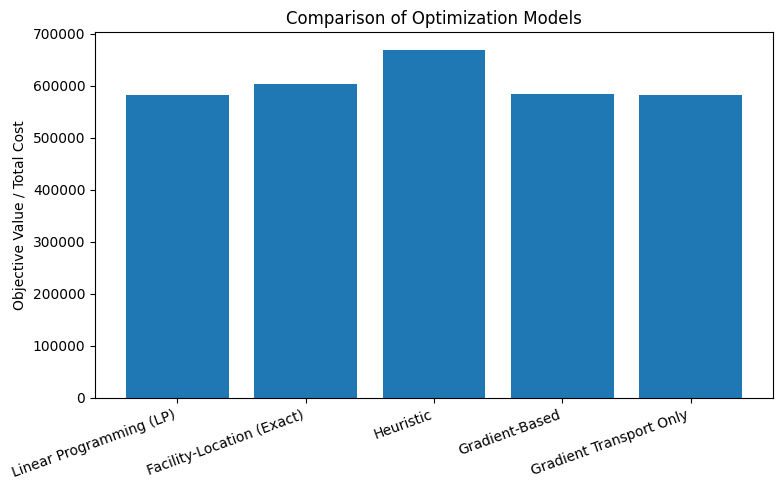

In [27]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["model"], comparison_df["value"])
plt.title("Comparison of Optimization Models")
plt.ylabel("Objective Value / Total Cost")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Step 27: Visualize sensitivity analysis results

In this step, a bar chart is created to compare the best total cost under each sensitivity-analysis scenario.

This helps show how changes in demand, transportation cost, and warehouse capacity affect the optimal network design.

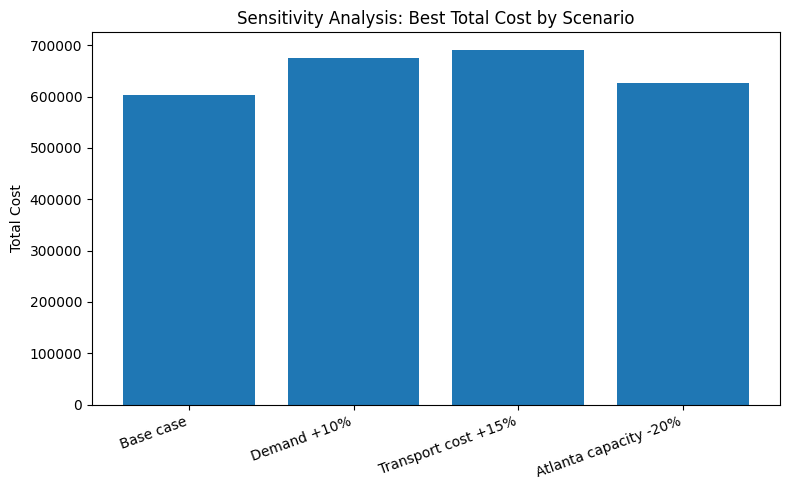

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(sensitivity_df["scenario"], sensitivity_df["total_cost"])
plt.title("Sensitivity Analysis: Best Total Cost by Scenario")
plt.ylabel("Total Cost")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Step 28: Summary of findings

The linear programming model minimized transportation cost and produced an optimal shipment plan with a total transportation cost of **$581,736.30**.

The exact facility-location analysis showed that the best warehouse configuration was **Atlanta, Dallas, Harrisburg, and Kansas City**, with a total cost of **$603,114.80** including fixed warehouse opening costs.

The heuristic approach produced a feasible but more expensive solution, with a total cost of **$668,839.60**, which was **10.9% higher** than the exact facility-location solution.

The gradient-based model produced a shipment allocation with transportation cost very close to the LP solution. Although the solver did not fully converge, the transportation component differed from the LP result by only **$103.15**, indicating that improved load balancing can be achieved with almost no increase in transportation cost.

Sensitivity analysis showed that the optimal network was more sensitive to demand growth and reduced Atlanta capacity than to a moderate increase in transportation cost. In both the **Demand +10%** and **Atlanta capacity -20%** scenarios, the model selected all five warehouses.